In [1]:
import pandas as pd
import numpy as np

In [2]:
train_df = pd.concat([pd.read_csv("../data/train_dataset.csv"), pd.read_csv("../data/val_dataset.csv")])
test_df = pd.read_csv("../data/test_dataset.csv")

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

X_train_text = train_df["text"]
y_train = train_df["sentiment"]
X_test_text = test_df["text"]
y_test = test_df["sentiment"]

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,
)

X_train = vectorizer.fit_transform(X_train_text)
X_val = vectorizer.transform(X_test_text)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,} features")

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

Vocabulary size: 1,051,749 features
Accuracy: 0.7412

              precision    recall  f1-score   support

    negative       0.81      0.82      0.82      4050
     neutral       0.91      0.39      0.55      3451
    positive       0.66      0.94      0.77      4499

    accuracy                           0.74     12000
   macro avg       0.79      0.72      0.71     12000
weighted avg       0.78      0.74      0.72     12000




--- super_short (4000 samples) ---
  Accuracy:  0.785
  F1 (macro): 0.770
  F1 per class: neg=0.813  neu=0.675  pos=0.822

--- short (4001 samples) ---
  Accuracy:  0.739
  F1 (macro): 0.717
  F1 per class: neg=0.817  neu=0.565  pos=0.769

--- medium (2000 samples) ---
  Accuracy:  0.736
  F1 (macro): 0.681
  F1 per class: neg=0.822  neu=0.456  pos=0.765

--- long (1999 samples) ---
  Accuracy:  0.663
  F1 (macro): 0.563
  F1 per class: neg=0.809  neu=0.179  pos=0.701


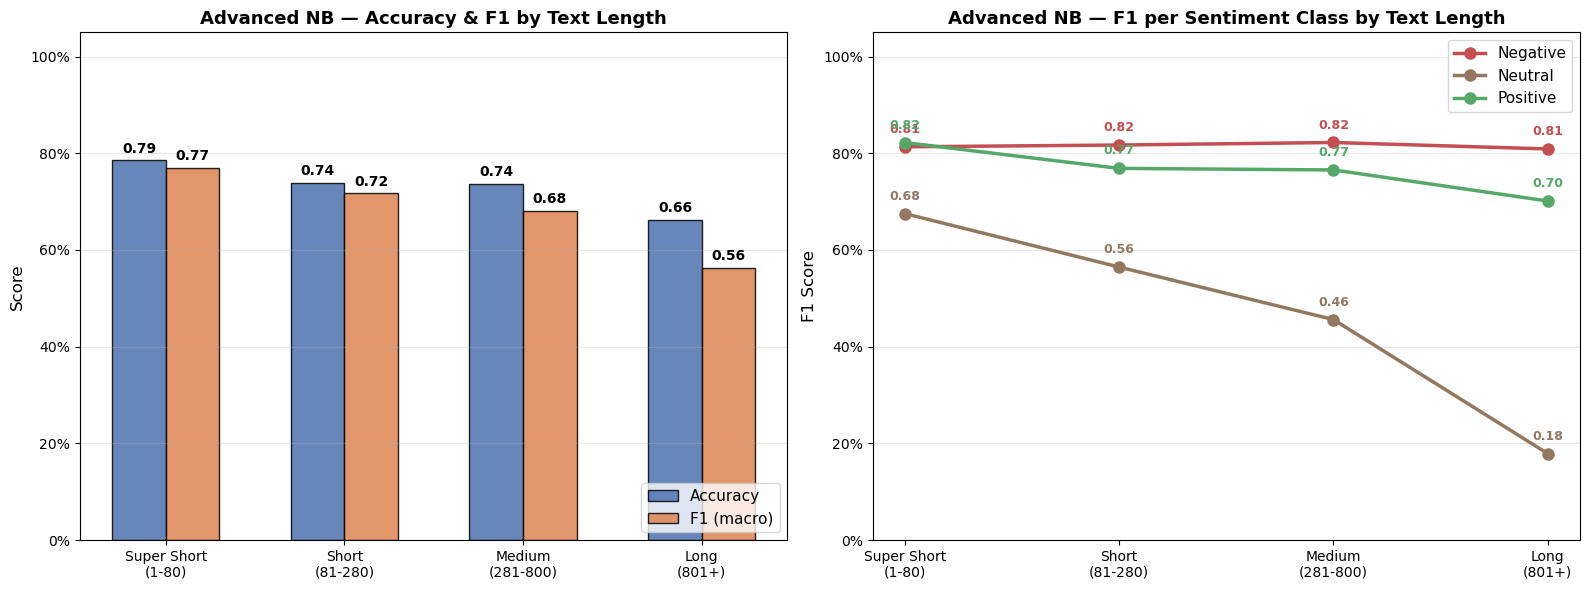

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.ticker as mticker

bucket_names = ["super_short", "short", "medium", "long"]
bucket_labels = ["Super Short\n(1-80)", "Short\n(81-280)", "Medium\n(281-800)", "Long\n(801+)"]

accuracies = []
f1_macros = []
f1_per_class = {"negative": [], "neutral": [], "positive": []}

for bucket in bucket_names:
    mask = test_df["bucket"] == bucket
    y_true_b = y_test[mask]
    y_pred_b = y_pred[mask]

    acc = accuracy_score(y_true_b, y_pred_b)
    f1_mac = f1_score(y_true_b, y_pred_b, average="macro", zero_division=0)
    accuracies.append(acc)
    f1_macros.append(f1_mac)

    for cls in ["negative", "neutral", "positive"]:
        f1_cls = f1_score(y_true_b, y_pred_b, average=None,
                          labels=["negative", "neutral", "positive"], zero_division=0)
        f1_per_class[cls].append(f1_cls[["negative", "neutral", "positive"].index(cls)])

    print(f"\n--- {bucket} ({mask.sum()} samples) ---")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  F1 (macro): {f1_mac:.3f}")
    print(f"  F1 per class: neg={f1_per_class['negative'][-1]:.3f}  "
          f"neu={f1_per_class['neutral'][-1]:.3f}  "
          f"pos={f1_per_class['positive'][-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(bucket_names))
width = 0.3

bars1 = ax1.bar(x - width/2, accuracies, width, label="Accuracy",
                color="#4C72B0", edgecolor="black", alpha=0.85)
bars2 = ax1.bar(x + width/2, f1_macros, width, label="F1 (macro)",
                color="#DD8452", edgecolor="black", alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_labels, fontsize=10)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("Advanced NB: Accuracy & F1 by Text Length", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

colors = {"negative": "#C44E52", "neutral": "#937860", "positive": "#55A868"}
for cls, color in colors.items():
    ax2.plot(x, f1_per_class[cls], marker="o", markersize=8, linewidth=2.5,
             label=cls.capitalize(), color=color)
    for i, val in enumerate(f1_per_class[cls]):
        ax2.annotate(f"{val:.2f}", (x[i], val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color=color)

ax2.set_xticks(x)
ax2.set_xticklabels(bucket_labels, fontsize=10)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_title("Advanced NB: F1 per Sentiment Class by Text Length", fontsize=13, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()